In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [46]:
path = kagglehub.dataset_download(
    "asaniczka/uk-optimal-product-price-prediction"
)

print(path)

/Users/salvadorciaurrizgonzalez/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3


In [47]:
import os

os.listdir(path)

['amz_uk_price_prediction_dataset.csv']

In [48]:
df = pd.read_csv(
    path + "/amz_uk_price_prediction_dataset.csv"
)

In [49]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [51]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [52]:
category_freq = df['category'].value_counts()

category_freq.head()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

In [53]:
top_5_categories = category_freq.head(5)

top_5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

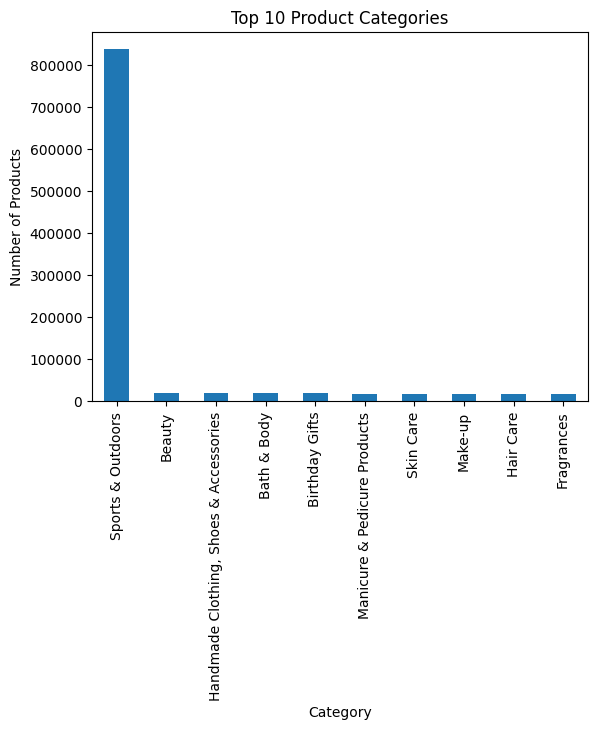

In [54]:
top_10_categories = category_freq.head(10)

top_10_categories.plot(kind='bar')

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

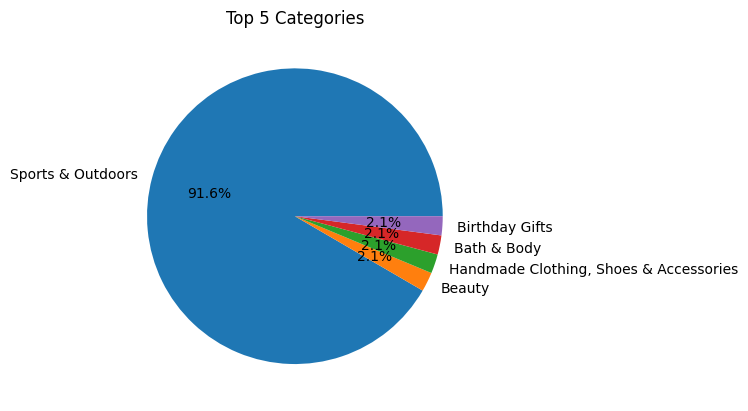

In [55]:
top_5_categories.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Top 5 Categories")

plt.show()

Some product categories dominate Amazon UK listings, concentrating a large proportion of products.

In [56]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

print("Mean:", mean_price)
print("Median:", median_price)
print("Mode:", mode_price)

Mean: 89.24380943923663
Median: 19.09
Mode: 9.99


In [57]:
variance_price = df['price'].var()

std_price = df['price'].std()

range_price = (
    df['price'].max()
    - df['price'].min()
)

iqr_price = (
    df['price'].quantile(0.75)
    - df['price'].quantile(0.25)
)

print("Variance:", variance_price)
print("Std:", std_price)
print("Range:", range_price)
print("IQR:", iqr_price)

Variance: 119445.48532254907
Std: 345.60886175349884
Range: 100000.0
IQR: 36.0


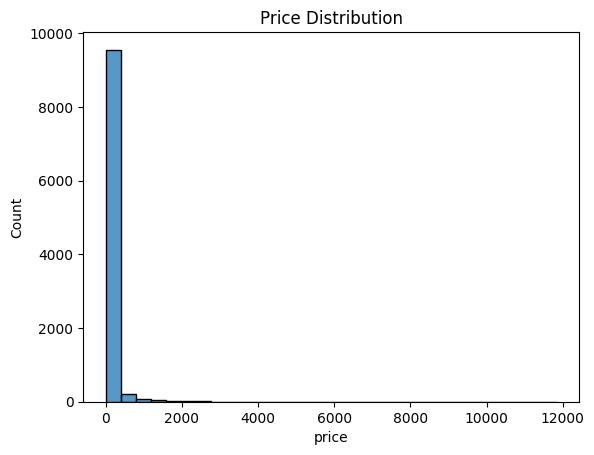

In [58]:
sample_prices = df['price'].sample(10000)

sns.histplot(sample_prices, bins=30)

plt.title("Price Distribution")

plt.show()

The histogram is difficult to interpret because of extreme outliers that compress most price values into a small range.

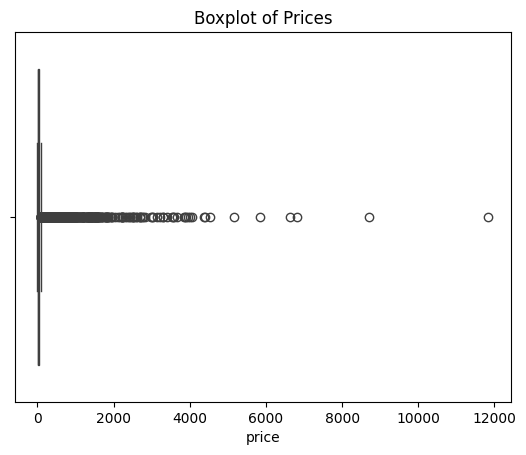

In [59]:
sns.boxplot(x=sample_prices)

plt.title("Boxplot of Prices")

plt.show()

There are significant outliers, meaning some products are priced much higher than the majority.

In [60]:
mean_rating = df['stars'].mean()

median_rating = df['stars'].median()

mode_rating = df['stars'].mode()[0]

print(mean_rating)
print(median_rating)
print(mode_rating)

2.152836472966065
0.0
0.0


In [61]:
variance_rating = df['stars'].var()

std_rating = df['stars'].std()

iqr_rating = (
    df['stars'].quantile(0.75)
    - df['stars'].quantile(0.25)
)

print(variance_rating)
print(std_rating)
print(iqr_rating)

4.817434029796862
2.1948653785134207
4.4


In [62]:
skewness = df['stars'].skew()

kurtosis = df['stars'].kurt()

print(skewness)
print(kurtosis)

0.08120735761080985
-1.9260061280432985


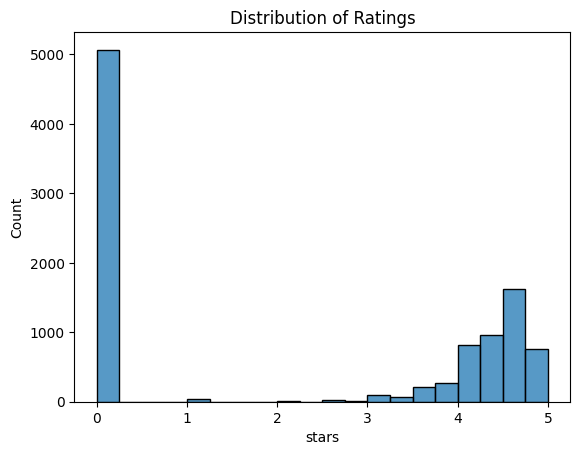

In [63]:
sample_stars = df['stars'].sample(10000)

sns.histplot(sample_stars, bins=20)

plt.title("Distribution of Ratings")

plt.show()

Ratings tend to cluster around high values, suggesting that customers generally leave positive reviews.

The distribution is negatively skewed because most products have high ratings.

## Conclusion

Amazon UK product listings show strong concentration in a few categories.

Most products are relatively low-priced, although there are significant outliers.

Customer ratings tend to be very positive overall.